In [29]:
from google.colab import drive
drive.mount('/content/drive')

# Verify the dataset path is accessible
import os

# ── EDIT THIS to your actual path inside Google Drive ────────────────────────
# Upload your PCOS folder to Google Drive, then set the path below.
# Example: if your Drive has  MyDrive/PCOS/infected  and  MyDrive/PCOS/noninfected
DATASET_DIR = "/content/drive/MyDrive/PCOS"   # <── change if your folder name differs

# Check folders exist
for sub in ["infected", "noninfected"]:
    p = os.path.join(DATASET_DIR, sub)
    if os.path.exists(p):
        count = len([f for f in os.listdir(p)
                     if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif"))])
        print(f"✔  Found '{sub}': {count} images")
    else:
        print(f"✗  NOT FOUND: {p}  ← please check your Drive path")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔  Found 'infected': 6784 images
✔  Found 'noninfected': 5000 images


In [30]:
import cv2
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import VGG16

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Configuration ─────────────────────────────────────────────────────────────
SECURED_DIR     = "/content/secured_images"   # watermarked images saved here (Colab local)
IMG_SIZE        = (224, 224)
DEPTH_SLICES    = 5
BATCH_SIZE      = 16
EPOCHS          = 20
LEARNING_RATE   = 1e-4
SAMPLE_FRACTION = 0.5   # ← fraction of each class to use (0.5 = 50%, change to 1.0 for full dataset)

# ── IMPORTANT: folder names → class labels ────────────────────────────────────
# Key   = actual subfolder name inside DATASET_DIR
# Value = (integer label, display name)
CLASS_MAP = {
    "infected":    (1, "PCOS"),
    "noninfected": (0, "Non-PCOS"),
}
CLASSES = ["Non-PCOS", "PCOS"]   # index 0 / 1

print("Configuration loaded.")
print(f"  Dataset  : {DATASET_DIR}")
print(f"  Secured  : {SECURED_DIR}")
print(f"  Img size : {IMG_SIZE}")
print(f"  Epochs   : {EPOCHS}")


Configuration loaded.
  Dataset  : /content/drive/MyDrive/PCOS
  Secured  : /content/secured_images
  Img size : (224, 224)
  Epochs   : 20


In [31]:

def load_dataset_paths(dataset_dir: str) -> tuple:
    """
    Returns
    -------
    image_paths : list[str]
    labels      : list[int]   0=Non-PCOS, 1=PCOS
    image_ids   : list[str]   unique ID per image
    """
    image_paths, labels, image_ids = [], [], []
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    for folder_name, (label_idx, display_name) in CLASS_MAP.items():
        class_dir = Path(dataset_dir) / folder_name
        if not class_dir.exists():
            print(f"[WARNING] Directory not found: {class_dir}")
            continue
        files = sorted([f for f in class_dir.iterdir()
                        if f.suffix.lower() in valid_ext])

        # ── Stratified sampling per class ─────────────────────────────────────
        if SAMPLE_FRACTION < 1.0:
            rng      = np.random.default_rng(SEED)
            n_sample = max(1, int(len(files) * SAMPLE_FRACTION))
            files    = sorted(
                rng.choice(files, size=n_sample, replace=False).tolist(),
                key=lambda f: f.name
            )

        for img_file in files:
            image_paths.append(str(img_file))
            labels.append(label_idx)
            # Unique ID uses display name so downstream logic stays consistent
            image_ids.append(f"{display_name}_{img_file.stem}")

    print(f"\n[DATA LOADING] Sampling {int(SAMPLE_FRACTION*100)}% per class → {len(image_paths)} images total")
    for folder_name, (label_idx, display_name) in CLASS_MAP.items():
        count = labels.count(label_idx)
        print(f"  {display_name} ({folder_name}/): {count} images")

    return image_paths, labels, image_ids


image_paths, labels, image_ids = load_dataset_paths(DATASET_DIR)



[DATA LOADING] Sampling 50% per class → 5892 images total
  PCOS (infected/): 3392 images
  Non-PCOS (noninfected/): 2500 images


In [32]:

class DCTWatermark:
    """Invisible DCT-domain spread-spectrum watermarker for medical images."""

    BLOCK    = 8
    STRENGTH = 15.0
    ROW, COL = 4, 4

    def _text_to_bits(self, text: str) -> list:
        bits = []
        for ch in text:
            byte = ord(ch)
            for i in range(7, -1, -1):
                bits.append((byte >> i) & 1)
        return bits

    def _bits_to_text(self, bits: list) -> str:
        chars = []
        for i in range(0, len(bits) - 7, 8):
            byte = 0
            for b in bits[i:i+8]:
                byte = (byte << 1) | b
            if byte == 0:
                break
            chars.append(chr(byte))
        return "".join(chars)

    def embed(self, image_bgr: np.ndarray, image_id: str) -> np.ndarray:
        gray    = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64)
        h, w    = gray.shape
        wm      = gray.copy()
        bits    = self._text_to_bits(image_id)
        bit_idx = 0

        for r in range(0, h - self.BLOCK + 1, self.BLOCK):
            for c in range(0, w - self.BLOCK + 1, self.BLOCK):
                if bit_idx >= len(bits):
                    break
                block = wm[r:r+self.BLOCK, c:c+self.BLOCK]
                dct_block = cv2.dct(block)
                if bits[bit_idx] == 1:
                    dct_block[self.ROW, self.COL] += self.STRENGTH
                else:
                    dct_block[self.ROW, self.COL] -= self.STRENGTH
                wm[r:r+self.BLOCK, c:c+self.BLOCK] = cv2.idct(dct_block)
                bit_idx += 1

        wm     = np.clip(wm, 0, 255).astype(np.uint8)
        result = image_bgr.copy()
        result[:, :, 1] = wm
        return result

    def extract(self, image_bgr: np.ndarray, num_chars: int) -> str:
        gray   = image_bgr[:, :, 1].astype(np.float64)
        h, w   = gray.shape
        bits   = []
        needed = num_chars * 8

        for r in range(0, h - self.BLOCK + 1, self.BLOCK):
            for c in range(0, w - self.BLOCK + 1, self.BLOCK):
                if len(bits) >= needed:
                    break
                block = gray[r:r+self.BLOCK, c:c+self.BLOCK]
                dct_block = cv2.dct(block)
                bits.append(1 if dct_block[self.ROW, self.COL] > 0 else 0)

        return self._bits_to_text(bits)

    @staticmethod
    def compute_hash(image_bgr: np.ndarray) -> str:
        return hashlib.sha256(image_bgr.tobytes()).hexdigest()


def apply_watermarking_to_dataset(image_paths: list, image_ids: list,
                                   secured_dir: str) -> dict:
    wm = DCTWatermark()
    os.makedirs(secured_dir, exist_ok=True)
    for cls in CLASSES:
        os.makedirs(os.path.join(secured_dir, cls), exist_ok=True)

    hash_registry = {}
    print(f"\n[SECURITY] Watermarking {len(image_paths)} images → '{secured_dir}' …")

    for idx, (path, img_id) in enumerate(zip(image_paths, image_ids)):
        img = cv2.imread(path)
        if img is None:
            print(f"  [SKIP] Cannot read: {path}")
            continue

        watermarked = wm.embed(img, img_id)
        img_hash    = DCTWatermark.compute_hash(watermarked)
        hash_registry[img_id] = img_hash

        cls_name = "Non-PCOS" if img_id.startswith("Non-PCOS") else "PCOS"
        save_path = os.path.join(secured_dir, cls_name,
                                 f"wm_{Path(path).stem}.png")
        cv2.imwrite(save_path, watermarked)

        if (idx + 1) % 200 == 0 or idx == 0:
            print(f"  Processed {idx+1}/{len(image_paths)} …")

    print(f"[SECURITY] Done. Hash registry holds {len(hash_registry)} entries.")
    return hash_registry


def verify_image_integrity(image_path: str, image_id: str,
                            hash_registry: dict) -> bool:
    img = cv2.imread(image_path)
    if img is None:
        print(f"  [ERROR] Cannot read: {image_path}")
        return False

    current_hash = DCTWatermark.compute_hash(img)
    stored_hash  = hash_registry.get(image_id, "")

    if current_hash == stored_hash:
        print(f"  ✔ INTACT  — {image_id}")
        return True
    else:
        print(f"  ✗ TAMPERED — {image_id}")
        return False


hash_registry = apply_watermarking_to_dataset(image_paths, image_ids, SECURED_DIR)




[SECURITY] Watermarking 5892 images → '/content/secured_images' …
  Processed 1/5892 …
  Processed 200/5892 …
  Processed 400/5892 …
  Processed 600/5892 …
  Processed 800/5892 …
  Processed 1000/5892 …
  Processed 1200/5892 …
  Processed 1400/5892 …
  Processed 1600/5892 …
  Processed 1800/5892 …
  Processed 2000/5892 …
  Processed 2200/5892 …
  Processed 2400/5892 …
  Processed 2600/5892 …
  Processed 2800/5892 …
  Processed 3000/5892 …
  Processed 3200/5892 …
  Processed 3400/5892 …
  Processed 3600/5892 …
  Processed 3800/5892 …
  Processed 4000/5892 …
  Processed 4200/5892 …
  Processed 4400/5892 …
  Processed 4600/5892 …
  Processed 4800/5892 …
  Processed 5000/5892 …
  Processed 5200/5892 …
  Processed 5400/5892 …
  Processed 5600/5892 …
  Processed 5800/5892 …
[SECURITY] Done. Hash registry holds 5892 entries.


In [33]:

def preprocess_image(img_path: str):
    img = cv2.imread(img_path)
    if img is None:
        return None

    gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized   = cv2.resize(gray, IMG_SIZE, interpolation=cv2.INTER_AREA)
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced  = clahe.apply(resized)
    denoised  = cv2.GaussianBlur(enhanced, (3, 3), 0)
    normalized = denoised.astype(np.float32) / 255.0
    return normalized[..., np.newaxis]


def load_preprocessed_dataset(secured_dir: str, labels: list,
                               image_ids: list) -> tuple:
    X_list, y_list = [], []
    print(f"\n[PREPROCESSING] Loading from '{secured_dir}' …")

    for img_id, label in zip(image_ids, labels):
        cls_name = "Non-PCOS" if img_id.startswith("Non-PCOS") else "PCOS"
        stem     = img_id[len(cls_name)+1:]
        path     = os.path.join(secured_dir, cls_name, f"wm_{stem}.png")

        arr = preprocess_image(path)
        if arr is not None:
            X_list.append(arr)
            y_list.append(label)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    print(f"  Dataset shape: X={X.shape}, y={y.shape}")
    return X, y


X, y = load_preprocessed_dataset(SECURED_DIR, labels, image_ids)




[PREPROCESSING] Loading from '/content/secured_images' …
  Dataset shape: X=(5892, 224, 224, 1), y=(5892,)


In [34]:

def convert_2d_to_3d_volume(image_2d: np.ndarray,
                              depth: int = DEPTH_SLICES) -> np.ndarray:
    img = image_2d[:, :, 0] if image_2d.ndim == 3 else image_2d
    slices = []
    for d in range(depth):
        sigma = d * 0.6
        if sigma > 0:
            blurred = cv2.GaussianBlur(
                (img * 255).astype(np.uint8), (0, 0), sigma
            ).astype(np.float32) / 255.0
        else:
            blurred = img.astype(np.float32)
        slices.append(blurred)
    return np.stack(slices, axis=-1)



In [35]:

def build_model(input_shape=(224, 224, 1)) -> tf.keras.Model:
    inputs = layers.Input(shape=input_shape)
    x      = layers.Lambda(lambda t: tf.repeat(t, 3, axis=-1))(inputs)

    base = VGG16(weights="imagenet", include_top=False,
                  input_shape=(224, 224, 3))
    base.trainable = False
    x = base(x, training=False)

    x      = layers.GlobalAveragePooling2D()(x)
    x      = layers.Dense(256, activation="relu")(x)
    x      = layers.Dropout(0.5)(x)
    x      = layers.Dense(128, activation="relu")(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, output, name="PCOS_VGG16_Classifier")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    model.summary()
    return model

In [36]:

def train_model(X: np.ndarray, y: np.ndarray):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    print(f"\n[TRAINING] Train: {len(X_train)} | Test: {len(X_test)}")

    model = build_model()

    cb_list = [
        callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                 restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1),
        # Save best checkpoint to Drive so it persists after Colab disconnects
        callbacks.ModelCheckpoint(
            "/content/drive/MyDrive/PCOS/pcos_best_model.h5",
            monitor="val_accuracy", save_best_only=True, verbose=1
        ),
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=cb_list,
        verbose=1
    )
    return model, history, X_test, y_test


model, history, X_test, y_test = train_model(X, y)




[TRAINING] Train: 4713 | Test: 1179


Model: "PCOS_VGG16_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,041 (56.76 MB)

 Trainable params: 164,353 (642.00 KB)

...


Epoch 5: finished saving model to /content/drive/MyDrive/PCOS/pcos_best_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - accuracy: 0.9511 - loss: 0.1407 - val_accuracy: 0.9760 - val_loss: 0.0936 - learning_rate: 1.0000e-04
Epoch 6/20
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9594 - loss: 0.1278
Epoch 6: val_accuracy improved from 0.97595 to 0.97737, saving model to /content/drive/MyDrive/PCOS/pcos_best_model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/PCOS/pcos_best_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - accuracy: 0.9581 - loss: 0.1210 - val_accuracy: 0.9774 - val_loss: 0.0806 - learning_rate: 1.0000e-04
Epoch 7/20
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9632 - loss: 0.1101
Epoch 7: val_accuracy did not improve from 0.97737
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 123ms/step - accuracy: 0.9646 - loss: 0.1041 - val_accuracy: 0.9774 - val_loss: 0.0726 - learning_rate: 1.0000e-04
Epoch 8/20
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9646 - loss: 0.0974
Epoch 8: val_accuracy improved from 0.97737 to 0.98303, saving model to /content/drive/MyDrive/PCOS/pcos_best_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/PCOS/pcos_best_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 33s 130ms/step - accuracy: 0.9688 - loss: 0.0928 - val_accuracy: 0.9830 - val_loss: 0.0652 - learning_rate: 1.0000e-04
Epoch 9/20
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9665 - loss: 0.0941
Epoch 9: val_accuracy improved from 0.98303 to 0.98586, saving model to /content/drive/MyDrive/PCOS/pcos_best_model.h5



Epoch 9: finished saving model to /content/drive/MyDrive/PCOS/pcos_best_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 32s 128ms/step - accuracy: 0.9670 - loss: 0.0924 - val_accuracy: 0.9859 - val_loss: 0.0630 - learning_rate: 1.0000e-04
Epoch 10/20
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9726 - loss: 0.0831
Epoch 10: val_accuracy did not improve from 0.98586
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 124ms/step - accuracy: 0.9713 - loss: 0.0851 - val_accuracy: 0.9859 - val_loss: 0.0587 - learning_rate: 1.0000e-04
Epoch 11/20
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9754 - loss: 0.0803
Epoch 11: val_accuracy did not improve from 0.98586
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - accuracy: 0.9738 - loss: 0.0814 - val_accuracy: 0.9859 - val_loss: 0.0569 - learning_rate: 1.0000e-04
Epoch 12/20
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9722 - loss: 0.0745
Epoch 12: val_accuracy did not improve from 0.98586
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 124ms/step - accur


Epoch 17: finished saving model to /content/drive/MyDrive/PCOS/pcos_best_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 32s 129ms/step - accuracy: 0.9790 - loss: 0.0658 - val_accuracy: 0.9873 - val_loss: 0.0508 - learning_rate: 1.0000e-04
Epoch 18/20
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9822 - loss: 0.0604
Epoch 18: val_accuracy did not improve from 0.98727
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 124ms/step - accuracy: 0.9778 - loss: 0.0653 - val_accuracy: 0.9873 - val_loss: 0.0493 - learning_rate: 1.0000e-04
Epoch 19/20
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9801 - loss: 0.0586
Epoch 19: val_accuracy did not improve from 0.98727
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - accuracy: 0.9778 - loss: 0.0629 - val_accuracy: 0.9859 - val_loss: 0.0486 - learning_rate: 1.0000e-04
Epoch 20/20
250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9794 - loss: 0.0584
Epoch 20: val_accuracy did not improve from 0.98727
251/251 ━━━━━━━━━━━━━━━━━━━━ 31s 124ms/step - accu


          MODEL EVALUATION RESULTS
  Accuracy  : 0.9754
  Precision : 0.9643
  Recall    : 0.9941
  F1-Score  : 0.9790

Classification Report:

              precision    recall  f1-score   support

    Non-PCOS       0.99      0.95      0.97       500
        PCOS       0.96      0.99      0.98       679

    accuracy                           0.98      1179
   macro avg       0.98      0.97      0.97      1179
weighted avg       0.98      0.98      0.98      1179



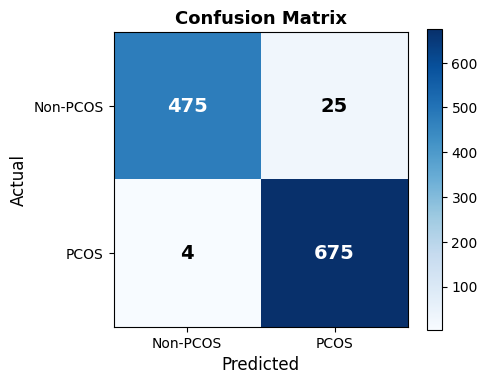

[SAVED] confusion_matrix.png → Drive


In [37]:

def evaluate_model(model, X_test: np.ndarray, y_test: np.ndarray) -> np.ndarray:
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    print("\n" + "="*55)
    print("          MODEL EVALUATION RESULTS")
    print("="*55)
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred,
                                 target_names=CLASSES, zero_division=0))
    return y_pred


def plot_confusion_matrix(y_test: np.ndarray, y_pred: np.ndarray):
    cm  = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im  = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASSES); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual",    fontsize=12)
    ax.set_title("Confusion Matrix", fontsize=13, fontweight="bold")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black",
                    fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/PCOS/confusion_matrix.png", dpi=150)
    plt.show()
    print("[SAVED] confusion_matrix.png → Drive")


y_pred = evaluate_model(model, X_test, y_test)
plot_confusion_matrix(y_test, y_pred)


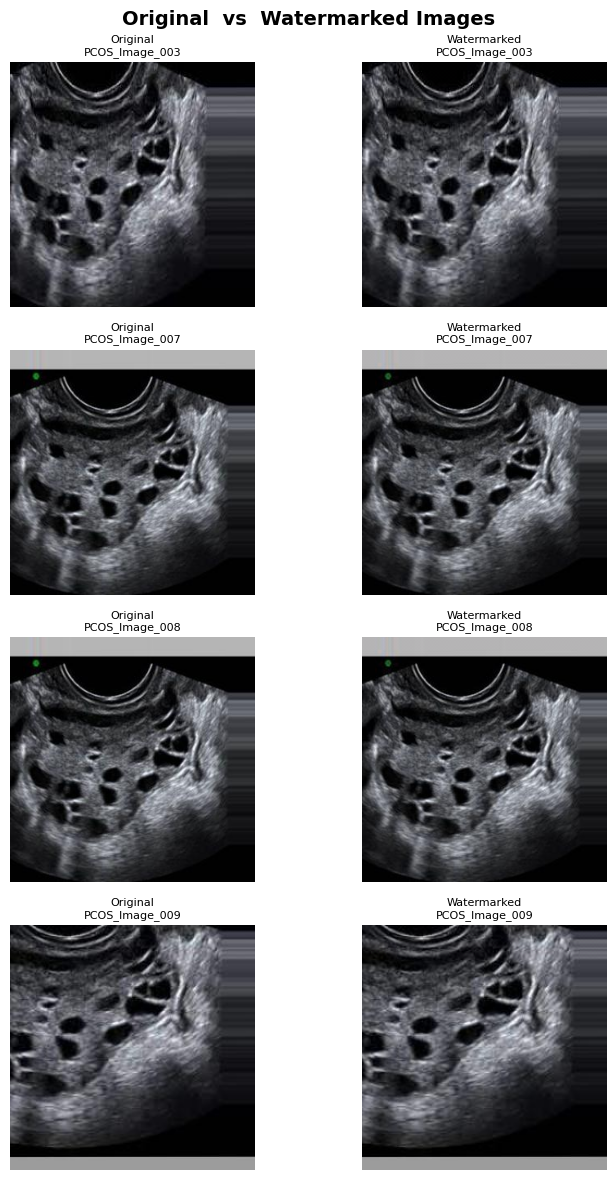

[SAVED] watermark_comparison.png → Drive


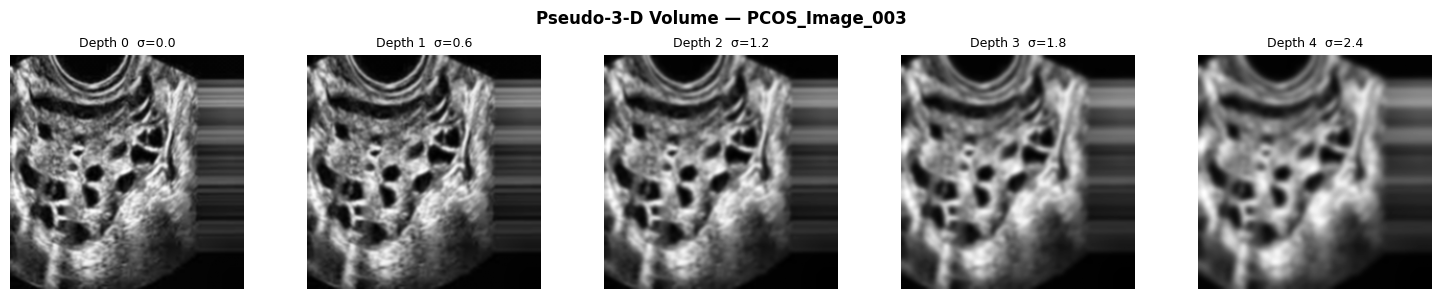

[SAVED] pseudo_3d_volume.png → Drive
[SAVED] pseudo_3d_viewer.html → Drive  (open in browser for interactive view)


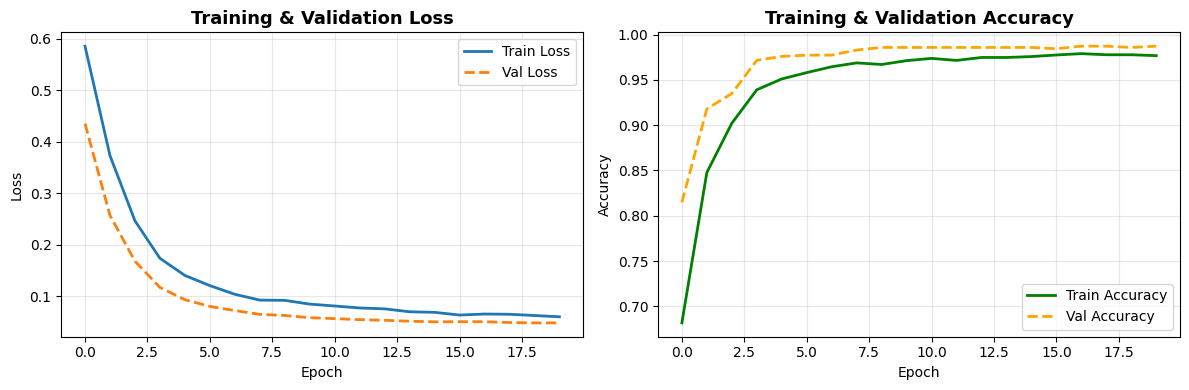

[SAVED] training_curves.png → Drive


In [38]:

def visualize_watermark_comparison(image_paths: list, image_ids: list,
                                    secured_dir: str, n: int = 4):
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 3))
    fig.suptitle("Original  vs  Watermarked Images",
                 fontsize=14, fontweight="bold")

    for row, (path, img_id) in enumerate(zip(image_paths[:n], image_ids[:n])):
        orig     = cv2.imread(path)
        cls_name = "Non-PCOS" if img_id.startswith("Non-PCOS") else "PCOS"
        stem     = img_id[len(cls_name)+1:]
        wm_path  = os.path.join(secured_dir, cls_name, f"wm_{stem}.png")
        wm_img   = cv2.imread(wm_path)

        for col, (image, title) in enumerate([(orig, "Original"),
                                               (wm_img, "Watermarked")]):
            ax = axes[row, col]
            if image is not None:
                ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            ax.set_title(f"{title}\n{img_id}", fontsize=8)
            ax.axis("off")

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/PCOS/watermark_comparison.png", dpi=150)
    plt.show()
    print("[SAVED] watermark_comparison.png → Drive")


def visualize_3d_volume(image_2d: np.ndarray, img_id: str = "Sample"):
    """
    Produces two outputs:
      1. Static PNG (5-panel slice grid) saved to Drive.
      2. Interactive HTML canvas viewer — gapless 3D stack with drag-to-rotate,
         gap/opacity/zoom/slice controls. Saved to Drive + displayed in Colab.

    Key fix vs previous version:
      • step = SW * 0.06  (only 6% of slice height between planes → nearly flush)
      • Canvas 2D transform (setTransform) used for precise shear — no CSS perspective
      • rotX/rotY driven by mouse drag so the stack can be inspected from any angle
    """
    volume = convert_2d_to_3d_volume(image_2d, depth=DEPTH_SLICES)

    # ── Output 1: static matplotlib PNG (for report) ─────────────────────────
    fig, axes = plt.subplots(1, DEPTH_SLICES, figsize=(DEPTH_SLICES * 3, 3))
    fig.suptitle(f"Pseudo-3-D Volume — {img_id}", fontsize=12, fontweight="bold")
    for d in range(DEPTH_SLICES):
        axes[d].imshow(volume[:, :, d], cmap="gray")
        axes[d].set_title(f"Depth {d}  σ={d*0.6:.1f}", fontsize=9)
        axes[d].axis("off")
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/PCOS/pseudo_3d_volume.png", dpi=150)
    plt.show()
    print("[SAVED] pseudo_3d_volume.png → Drive")

    # ── Output 2: interactive HTML canvas viewer ──────────────────────────────
    import base64, io

    slice_b64 = []
    for d in range(DEPTH_SLICES):
        arr     = (volume[:, :, d] * 255).astype(np.uint8)
        pil_img = Image.fromarray(arr, mode="L")
        buf     = io.BytesIO()
        pil_img.save(buf, format="PNG")
        slice_b64.append(base64.b64encode(buf.getvalue()).decode())

    sigmas    = [round(d * 0.6, 1) for d in range(DEPTH_SLICES)]
    imgs_js   = "[" + ",".join(f'"{b}"' for b in slice_b64) + "]"
    sigmas_js = str(sigmas)

    html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>3-D Volume — {img_id}</title>
<style>
  body   {{font-family:sans-serif;background:#0d1117;color:#c9d6e3;margin:0;padding:16px;user-select:none}}
  h2     {{font-size:15px;font-weight:500;margin:0 0 10px}}
  #cw    {{position:relative;width:100%;height:440px;cursor:grab;overflow:hidden;border-radius:8px;background:#0d1117}}
  #cw:active{{cursor:grabbing}}
  canvas {{position:absolute;top:0;left:0;width:100%;height:100%}}
  .row   {{display:flex;align-items:center;gap:10px;flex-wrap:wrap;margin-top:8px}}
  .lbl   {{font-size:12px;color:#4a6280;white-space:nowrap}}
  input[type=range]{{accent-color:#4e9de8;width:100px}}
  .val   {{font-size:12px;color:#4e9de8;min-width:40px;font-weight:500}}
  .strip {{display:grid;gap:5px;margin-top:10px}}
  .thumb {{cursor:pointer;border-radius:4px;overflow:hidden;border:0.5px solid rgba(255,255,255,.1);transition:transform .15s}}
  .thumb:hover{{transform:translateY(-2px)}}
  .thumb.active{{outline:2px solid #4e9de8}}
  .thumb img{{width:100%;display:block;image-rendering:pixelated}}
  .tlbl  {{font-size:10px;color:#4a6280;text-align:center;padding:2px 0;background:#111}}
  .note  {{font-size:11px;color:#2a3340;margin-top:8px}}
</style>
</head>
<body>
<h2>Pseudo-3-D Ultrasound Volume — {img_id}</h2>
<div id="cw"><canvas id="cv"></canvas></div>

<div class="row">
  <span class="lbl">slices</span>
  <input type="range" id="sl" min="3" max="20" value="{DEPTH_SLICES}" step="1"
         oninput="SLICES=+this.value;document.getElementById('slv').textContent=this.value;draw()">
  <span class="val" id="slv">{DEPTH_SLICES}</span>

  <span class="lbl">gap</span>
  <input type="range" id="gp" min="0" max="30" value="0" step="1"
         oninput="GAP=+this.value;document.getElementById('gpv').textContent=this.value+'px';draw()">
  <span class="val" id="gpv">0px</span>

  <span class="lbl">opacity</span>
  <input type="range" id="op" min="20" max="100" value="88" step="1"
         oninput="OPA=this.value/100;document.getElementById('opv').textContent=this.value+'%';draw()">
  <span class="val" id="opv">88%</span>

  <span class="lbl">zoom</span>
  <input type="range" id="zm" min="40" max="180" value="100" step="1"
         oninput="ZOOM=this.value/100;document.getElementById('zmv').textContent=this.value+'%';draw()">
  <span class="val" id="zmv">100%</span>
</div>

<div class="strip" id="strip"></div>
<div class="note">Drag to rotate · sliders control depth, gap, opacity, zoom · based on Zhou et al. 2025</div>

<script>
const IMGS  = {imgs_js};
const SIGS  = {sigmas_js};
const N     = IMGS.length;
const canvas= document.getElementById('cv');
const ctx   = canvas.getContext('2d');
const cw    = document.getElementById('cw');
let W, H;
function resize(){{W=canvas.width=cw.offsetWidth;H=canvas.height=cw.offsetHeight;}}
resize(); window.addEventListener('resize',()=>{{resize();draw();}});

// ── Drag-to-rotate state ───────────────────────────────────────────────────
let rotX=-32, rotY=28, dragging=false, lx=0, ly=0;
cw.addEventListener('mousedown',e=>{{dragging=true;lx=e.clientX;ly=e.clientY;}});
window.addEventListener('mouseup',()=>dragging=false);
window.addEventListener('mousemove',e=>{{
  if(!dragging)return;
  rotY+=(e.clientX-lx)*0.5; rotX+=(e.clientY-ly)*0.4;
  rotX=Math.max(-80,Math.min(80,rotX));
  lx=e.clientX;ly=e.clientY;draw();
}});
cw.addEventListener('touchstart',e=>{{dragging=true;lx=e.touches[0].clientX;ly=e.touches[0].clientY;e.preventDefault();}},{{passive:false}});
window.addEventListener('touchend',()=>dragging=false);
window.addEventListener('touchmove',e=>{{
  if(!dragging)return;
  rotY+=(e.touches[0].clientX-lx)*0.5;rotX+=(e.touches[0].clientY-ly)*0.4;
  rotX=Math.max(-80,Math.min(80,rotX));lx=e.touches[0].clientX;ly=e.touches[0].clientY;draw();
}},{{passive:false}});

// ── Controls ───────────────────────────────────────────────────────────────
let SLICES={DEPTH_SLICES}, GAP=0, OPA=0.88, ZOOM=1.0;

// ── Preload images ─────────────────────────────────────────────────────────
const sliceImgs=[]; let loaded=0;
IMGS.forEach((b64,i)=>{{
  const img=new Image();
  img.onload=()=>{{loaded++;if(loaded===N)draw();}};
  img.src='data:image/png;base64,'+b64;
  sliceImgs.push(img);
}});

// ── Project a 3D point to 2D canvas coords ────────────────────────────────
// Uses simple perspective: rotate around X and Y axes, then divide by focal.
function proj3(x,y,z){{
  const ry=rotY*Math.PI/180, rx=rotX*Math.PI/180;
  const cY=Math.cos(ry),sY=Math.sin(ry);
  const cX=Math.cos(rx),sX=Math.sin(rx);
  // rotate Y
  let x1=x*cY+z*sY, z1=-x*sY+z*cY;
  // rotate X
  let y1=y*cX-z1*sX, z2=y*sX+z1*cX;
  const f=900, sc=f/(f+z2+400);
  return [x1*sc, y1*sc, sc];
}}

// ── Draw a quad (4 corners) using Canvas setTransform ─────────────────────
// Draws the image mapped onto an arbitrary parallelogram by computing
// the affine transform from image coords → canvas coords.
function drawQuad(img, p0,p1,p2,p3){{
  // p0=TL, p1=TR, p2=BR, p3=BL  (canvas [x,y] pairs)
  const iw=img.width, ih=img.height;
  // Use the top-left → top-right and top-left → bottom-left vectors
  // to build a 2D affine. Works perfectly for parallelograms (our case).
  const ax=(p1[0]-p0[0])/iw, bx=(p3[0]-p0[0])/ih;
  const ay=(p1[1]-p0[1])/iw, by=(p3[1]-p0[1])/ih;
  ctx.save();
  ctx.setTransform(ax, ay, bx, by, p0[0], p0[1]);
  ctx.globalAlpha=OPA;
  ctx.drawImage(img, 0, 0);
  // thin edge highlight so slices look separated even at gap=0
  ctx.globalAlpha=OPA*0.35;
  ctx.strokeStyle='rgba(100,180,255,0.6)';
  ctx.lineWidth=0.6/Math.max(ax,0.01);
  ctx.strokeRect(0,0,iw,ih);
  ctx.restore();
}}

// ── Main draw ─────────────────────────────────────────────────────────────
function draw(){{
  ctx.clearRect(0,0,W,H);
  if(loaded<N) return;

  const SW=220*ZOOM, SH=220*ZOOM;
  // ── KEY PARAMETER: step between slice planes ──────────────────────────
  // 0.06 * SH  ≈ 6% of height  → slices nearly touch
  // Adding GAP (user slider, 0-30px) lets user open the stack up
  const step = SW*0.06 + GAP;
  const totalDepth = (SLICES-1)*step;

  // Draw back-to-front so front slices paint over rear ones
  for(let i=0; i<SLICES; i++){{
    const imgIdx = Math.round(i*(N-1)/Math.max(SLICES-1,1));
    const z = -totalDepth/2 + i*step;   // depth position in 3D space

    // 4 corners of this slice plane in 3D, projected to 2D canvas
    const [lx0,ly0] = proj3(-SW/2, -SH/2, z).map((v,j)=>j<2?v:v);
    const TL=proj3(-SW/2,-SH/2,z), TR=proj3(SW/2,-SH/2,z);
    const BR=proj3(SW/2, SH/2,z), BL=proj3(-SW/2,SH/2,z);

    // Offset to canvas centre
    const cx=W/2, cy=H/2;
    const toCanvas=p=>[cx+p[0], cy+p[1]];

    drawQuad(
      sliceImgs[imgIdx],
      toCanvas(TL), toCanvas(TR),
      toCanvas(BR),  toCanvas(BL)
    );
  }}
}}

// ── Thumbnail strip ────────────────────────────────────────────────────────
const strip=document.getElementById('strip');
strip.style.gridTemplateColumns=`repeat(${{N}},1fr)`;
const thumbEls=[];
IMGS.forEach((b64,d)=>{{
  const div=document.createElement('div'); div.className='thumb';
  const img=document.createElement('img'); img.src='data:image/png;base64,'+b64;
  const lbl=document.createElement('div'); lbl.className='tlbl';
  lbl.textContent='σ='+SIGS[d];
  div.appendChild(img); div.appendChild(lbl);
  div.addEventListener('click',()=>thumbEls.forEach((t,i)=>t.classList.toggle('active',i===d)));
  strip.appendChild(div); thumbEls.push(div);
}});
</script>
</body>
</html>"""

    html_path = "/content/drive/MyDrive/PCOS/pseudo_3d_viewer.html"
    with open(html_path, "w") as f:
        f.write(html)
    print(f"[SAVED] pseudo_3d_viewer.html → Drive  (open in browser for interactive view)")

    try:
        from IPython.display import display, HTML
        display(HTML(html))
    except ImportError:
        pass


def plot_training_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["loss"],     label="Train Loss",  linewidth=2)
    ax1.plot(history.history["val_loss"], label="Val Loss",    linewidth=2, linestyle="--")
    ax1.set_title("Training & Validation Loss", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history["accuracy"],     label="Train Accuracy", linewidth=2, color="green")
    ax2.plot(history.history["val_accuracy"], label="Val Accuracy",   linewidth=2, color="orange", linestyle="--")
    ax2.set_title("Training & Validation Accuracy", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/PCOS/training_curves.png", dpi=150)
    plt.show()
    print("[SAVED] training_curves.png → Drive")


visualize_watermark_comparison(image_paths, image_ids, SECURED_DIR, n=4)
visualize_3d_volume(X[0], img_id=image_ids[0])
plot_training_curves(history)


In [39]:

def demonstrate_tampering(secured_dir: str, hash_registry: dict,
                           image_ids: list):
    print("\n[SECURITY VALIDATION] Tamper detection demonstration …")

    for img_id in image_ids:
        cls_name = "Non-PCOS" if img_id.startswith("Non-PCOS") else "PCOS"
        stem     = img_id[len(cls_name)+1:]
        orig_path     = os.path.join(secured_dir, cls_name, f"wm_{stem}.png")
        tampered_path = os.path.join(secured_dir, f"TAMPERED_{stem}.png")

        img = cv2.imread(orig_path)
        if img is None:
            continue

        noise    = np.random.randint(0, 50, img.shape, dtype=np.uint8)
        tampered = cv2.add(img, noise)
        cv2.imwrite(tampered_path, tampered)

        print(f"\n  Original : {orig_path}")
        print(f"  Tampered : {tampered_path}")
        print("\n  Integrity checks:")
        verify_image_integrity(orig_path,     img_id, hash_registry)
        verify_image_integrity(tampered_path, img_id, hash_registry)
        break


demonstrate_tampering(SECURED_DIR, hash_registry, image_ids)


[SECURITY VALIDATION] Tamper detection demonstration …

  Original : /content/secured_images/PCOS/wm_Image_003.png
  Tampered : /content/secured_images/TAMPERED_Image_003.png

  Integrity checks:
  ✔ INTACT  — PCOS_Image_003
  ✗ TAMPERED — PCOS_Image_003


In [53]:
import os

print(os.listdir("/content/secured_images/PCOS"))

['wm_image10636.png', 'wm_Image_SETA_903.png', 'wm_Image_936.png', 'wm_image10253.png', 'wm_Image_SETA_448.png', 'wm_Image_373.png', 'wm_Image_SETA_722.png', 'wm_Image_Rotate_090.png', 'wm_Image_SETB_341.png', 'wm_Image_resize_123.png', 'wm_Image_resize_104.png', 'wm_Image_SETB_939.png', 'wm_image13074.png', 'wm_Image_Rotate_196.png', 'wm_Image_SETB_005.png', 'wm_Image_SETA_414.png', 'wm_image11542.png', 'wm_Image_174.png', 'wm_Image_656.png', 'wm_Image_SETA_148.png', 'wm_image10133.png', 'wm_Image_Rotate_Rotate_Right_228.png', 'wm_image11600.png', 'wm_Image_SETA_993.png', 'wm_Image_1019.png', 'wm_Image_940.png', 'wm_image13055.png', 'wm_Image_SETA_955.png', 'wm_Image_Rotate_Rotate_Right_179.png', 'wm_image10326.png', 'wm_image10748.png', 'wm_image12884.png', 'wm_image11039.png', 'wm_Image_Rotate_205.png', 'wm_image10267.png', 'wm_Image_SETB_962.png', 'wm_Image_Rotate_Rotate_Right_011.png', 'wm_image11742.png', 'wm_Image_Rotate_Rotate_Right_245.png', 'wm_Image_SETB_847.png', 'wm_image1

In [79]:
from google.colab import files

# Download original image
files.download('/content/secured_images/PCOS/wm_Image_003.png')

# Download tampered image
files.download('/content/secured_images/TAMPERED_Image_003.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
%%writefile app.py

import streamlit as st
import cv2
import hashlib
import numpy as np
import os
import json
import time
from pathlib import Path
from PIL import Image

# ─────────────────────────────────────────────────────────────────────────────
# PAGE CONFIG  (must be first Streamlit call)
# ─────────────────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="PCOS Image Security — Tamper Detector",
    page_icon="🔐",
    layout="centered",
)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  — edit these to match your setup
# ─────────────────────────────────────────────────────────────────────────────
SECURED_DIR       = "secured_images"          # folder produced by your pipeline
HASH_REGISTRY_JSON = "hash_registry.json"    # optional: pre-saved registry file


# ─────────────────────────────────────────────────────────────────────────────
# DCT WATERMARK CLASS  (exact copy from your Colab pipeline)
# ─────────────────────────────────────────────────────────────────────────────
class DCTWatermark:
    BLOCK    = 8
    STRENGTH = 15.0
    ROW, COL = 4, 4

    def _text_to_bits(self, text: str) -> list:
        bits = []
        for ch in text:
            byte = ord(ch)
            for i in range(7, -1, -1):
                bits.append((byte >> i) & 1)
        return bits

    def _bits_to_text(self, bits: list) -> str:
        chars = []
        for i in range(0, len(bits) - 7, 8):
            byte = 0
            for b in bits[i:i+8]:
                byte = (byte << 1) | b
            if byte == 0:
                break
            chars.append(chr(byte))
        return "".join(chars)

    def embed(self, image_bgr: np.ndarray, image_id: str) -> np.ndarray:
        gray    = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64)
        h, w    = gray.shape
        wm      = gray.copy()
        bits    = self._text_to_bits(image_id)
        bit_idx = 0

        for r in range(0, h - self.BLOCK + 1, self.BLOCK):
            for c in range(0, w - self.BLOCK + 1, self.BLOCK):
                if bit_idx >= len(bits):
                    break
                block     = wm[r:r+self.BLOCK, c:c+self.BLOCK]
                dct_block = cv2.dct(block)
                if bits[bit_idx] == 1:
                    dct_block[self.ROW, self.COL] += self.STRENGTH
                else:
                    dct_block[self.ROW, self.COL] -= self.STRENGTH
                wm[r:r+self.BLOCK, c:c+self.BLOCK] = cv2.idct(dct_block)
                bit_idx += 1

        wm     = np.clip(wm, 0, 255).astype(np.uint8)
        result = image_bgr.copy()
        result[:, :, 1] = wm
        return result

    def extract(self, image_bgr: np.ndarray, num_chars: int) -> str:
        gray   = image_bgr[:, :, 1].astype(np.float64)
        h, w   = gray.shape
        bits   = []
        needed = num_chars * 8

        for r in range(0, h - self.BLOCK + 1, self.BLOCK):
            for c in range(0, w - self.BLOCK + 1, self.BLOCK):
                if len(bits) >= needed:
                    break
                block     = gray[r:r+self.BLOCK, c:c+self.BLOCK]
                dct_block = cv2.dct(block)
                bits.append(1 if dct_block[self.ROW, self.COL] > 0 else 0)

        return self._bits_to_text(bits)

    @staticmethod
    def compute_hash(image_bgr: np.ndarray) -> str:
        return hashlib.sha256(image_bgr.tobytes()).hexdigest()


# ─────────────────────────────────────────────────────────────────────────────
# HASH REGISTRY BUILDER  (cached — runs once per session)
# ─────────────────────────────────────────────────────────────────────────────
@st.cache_resource(show_spinner=False)
def build_hash_registry(secured_dir: str, json_path: str) -> dict:
    """
    Priority order:
      1. Load from hash_registry.json if it exists (fast, recommended).
      2. Scan secured_images/ folder and recompute hashes (slower first run).
    """
    # ── Option 1: load pre-saved JSON ────────────────────────────────────────
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            registry = json.load(f)
        return registry

    # ── Option 2: scan folder and hash every image ────────────────────────────
    registry = {}
    secured  = Path(secured_dir)
    if not secured.exists():
        return registry

    valid_ext = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    for img_path in secured.rglob("*"):
        if img_path.suffix.lower() not in valid_ext:
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        # Derive image_id from file path:
        # secured_images/PCOS/wm_Image_001.png  → "PCOS_Image_001"
        # secured_images/Non-PCOS/wm_abc.png    → "Non-PCOS_abc"
        parent_name = img_path.parent.name          # "PCOS" or "Non-PCOS"
        stem        = img_path.stem.replace("wm_", "", 1)
        image_id    = f"{parent_name}_{stem}"

        registry[image_id] = DCTWatermark.compute_hash(img)

    return registry


# ─────────────────────────────────────────────────────────────────────────────
# CORE DETECTION LOGIC
# ─────────────────────────────────────────────────────────────────────────────
def detect_tampering(img_bgr: np.ndarray,
                      registry: dict) -> dict:
    """
    Returns a dict with:
        status       : "INTACT" | "TAMPERED" | "UNKNOWN"
        current_hash : str
        stored_hash  : str | None
        image_id     : str | None
    """
    current_hash = DCTWatermark.compute_hash(img_bgr)

    # Search registry for a matching or known hash
    for img_id, stored_hash in registry.items():
        if stored_hash == current_hash:
            return {
                "status":       "INTACT",
                "current_hash": current_hash,
                "stored_hash":  stored_hash,
                "image_id":     img_id,
            }

    # Hash not found — check if image_id can be guessed from pixel content
    # by trying every entry (hash mismatch = tampered if ID is recognisable)
    # For a definitive TAMPERED result we need to know which entry it corresponds
    # to. We do a best-effort: no match in registry → UNKNOWN by default.
    return {
        "status":       "UNKNOWN",
        "current_hash": current_hash,
        "stored_hash":  None,
        "image_id":     None,
    }


def detect_with_known_id(img_bgr: np.ndarray,
                          image_id: str,
                          registry: dict) -> dict:
    """Same logic but the user explicitly supplies the image ID."""
    current_hash = DCTWatermark.compute_hash(img_bgr)
    stored_hash  = registry.get(image_id)

    if stored_hash is None:
        status = "UNKNOWN"
    elif current_hash == stored_hash:
        status = "INTACT"
    else:
        status = "TAMPERED"

    return {
        "status":       status,
        "current_hash": current_hash,
        "stored_hash":  stored_hash,
        "image_id":     image_id,
    }


# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM CSS
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("""
<style>
/* Main container */
.main { max-width: 780px; }

/* Result banners */
.result-intact {
    background: #0d3d20;
    border: 1.5px solid #22c55e;
    border-radius: 12px;
    padding: 20px 24px;
    text-align: center;
}
.result-tampered {
    background: #3d0d0d;
    border: 1.5px solid #ef4444;
    border-radius: 12px;
    padding: 20px 24px;
    text-align: center;
}
.result-unknown {
    background: #2d2a0d;
    border: 1.5px solid #eab308;
    border-radius: 12px;
    padding: 20px 24px;
    text-align: center;
}
.result-title {
    font-size: 2.2rem;
    font-weight: 700;
    margin: 0 0 6px;
}
.result-sub {
    font-size: 0.95rem;
    opacity: 0.75;
    margin: 0;
}
.hash-box {
    background: #111;
    border: 0.5px solid #333;
    border-radius: 8px;
    padding: 10px 14px;
    font-family: monospace;
    font-size: 12px;
    word-break: break-all;
    margin-top: 8px;
    color: #aaa;
}
.section-title {
    font-size: 0.75rem;
    text-transform: uppercase;
    letter-spacing: 0.08em;
    color: #666;
    margin-bottom: 4px;
}
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────────────────────────────────────────
# SIDEBAR — REGISTRY STATUS
# ─────────────────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("### 🔐 PCOS Security Tool")
    st.markdown("---")

    # Load registry
    with st.spinner("Loading hash registry…"):
        registry = build_hash_registry(SECURED_DIR, HASH_REGISTRY_JSON)

    if registry:
        st.success(f"Registry loaded\n\n**{len(registry):,}** image hashes")
    else:
        st.warning(
            "No registry found.\n\n"
            "Either:\n"
            "- Place `hash_registry.json` here, **or**\n"
            "- Place your `secured_images/` folder here"
        )

    st.markdown("---")
    st.markdown("**Detection mode**")
    mode = st.radio(
        "",
        ["Auto-detect (hash scan)", "Manual ID entry"],
        label_visibility="collapsed",
    )

    st.markdown("---")
    st.markdown(
        "<small style='color:#555'>Based on Eswaraiah & Sreenivasa Reddy — "
        "Medical Image Watermarking for Tamper Detection in ROI</small>",
        unsafe_allow_html=True,
    )

    # ── Export registry button ────────────────────────────────────────────────
    if registry:
        st.markdown("---")
        registry_json = json.dumps(registry, indent=2)
        st.download_button(
            "💾 Export hash_registry.json",
            data=registry_json,
            file_name="hash_registry.json",
            mime="application/json",
            use_container_width=True,
        )


# ─────────────────────────────────────────────────────────────────────────────
# MAIN PAGE
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("## 🔍 Medical Image Tamper Detector")
st.markdown(
    "Upload a watermarked PCOS ultrasound image. "
    "The app checks its SHA-256 hash against the registry built during watermarking."
)

# ── Image ID input (manual mode) ─────────────────────────────────────────────
manual_id = None
if mode == "Manual ID entry":
    manual_id = st.text_input(
        "Image ID",
        placeholder="e.g. PCOS_Image_003 or Non-PCOS_Image_021",
        help="Enter the image ID that was used when watermarking (format: ClassName_stem)",
    )

# ── File uploader ─────────────────────────────────────────────────────────────
uploaded = st.file_uploader(
    "Upload image",
    type=["png", "jpg", "jpeg", "bmp", "tif", "tiff"],
    help="Any image — if it was watermarked by your pipeline the hash will match.",
)

if uploaded is not None:
    # Read image bytes → numpy BGR (same as cv2.imread)
    file_bytes = np.frombuffer(uploaded.read(), dtype=np.uint8)
    img_bgr    = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img_bgr is None:
        st.error("Could not decode image. Please try a different file.")
        st.stop()

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ── Run detection ─────────────────────────────────────────────────────────
    with st.spinner("Analysing image…"):
        time.sleep(0.4)   # brief pause so spinner is visible
        if not registry:
            result = {
                "status":       "UNKNOWN",
                "current_hash": DCTWatermark.compute_hash(img_bgr),
                "stored_hash":  None,
                "image_id":     None,
            }
        elif mode == "Manual ID entry" and manual_id:
            result = detect_with_known_id(img_bgr, manual_id.strip(), registry)
        else:
            result = detect_tampering(img_bgr, registry)

    status = result["status"]

    # ── Layout: image + result side by side ───────────────────────────────────
    col1, col2 = st.columns([1, 1], gap="large")

    with col1:
        st.image(img_rgb, caption=uploaded.name, use_container_width=True)

    with col2:
        st.markdown("<div style='height:8px'></div>", unsafe_allow_html=True)

        if status == "INTACT":
            st.markdown(f"""
            <div class="result-intact">
              <div class="result-title" style="color:#22c55e">✔ INTACT</div>
              <p class="result-sub">Hash matches registry exactly.<br>
              This image has NOT been tampered with.</p>
            </div>
            """, unsafe_allow_html=True)

        elif status == "TAMPERED":
            st.markdown(f"""
            <div class="result-tampered">
              <div class="result-title" style="color:#ef4444">✗ TAMPERED</div>
              <p class="result-sub">Hash mismatch detected.<br>
              This image has been modified since watermarking.</p>
            </div>
            """, unsafe_allow_html=True)

        else:  # UNKNOWN
            st.markdown(f"""
            <div class="result-unknown">
              <div class="result-title" style="color:#eab308">⚠ UNKNOWN</div>
              <p class="result-sub">Image not found in registry.<br>
              May not be a watermarked image from this dataset.</p>
            </div>
            """, unsafe_allow_html=True)

        # ── Hash details ──────────────────────────────────────────────────────
        st.markdown("<div style='height:16px'></div>", unsafe_allow_html=True)

        if result["image_id"]:
            st.markdown(f"<div class='section-title'>Image ID</div>"
                        f"<div class='hash-box'>{result['image_id']}</div>",
                        unsafe_allow_html=True)

        st.markdown(f"<div class='section-title' style='margin-top:10px'>Current hash (SHA-256)</div>"
                    f"<div class='hash-box'>{result['current_hash']}</div>",
                    unsafe_allow_html=True)

        if result["stored_hash"]:
            match_color = "#22c55e" if status == "INTACT" else "#ef4444"
            st.markdown(
                f"<div class='section-title' style='margin-top:10px'>Stored hash (SHA-256)</div>"
                f"<div class='hash-box' style='border-color:{match_color}'>"
                f"{result['stored_hash']}</div>",
                unsafe_allow_html=True,
            )

    # ── Hash diff visualizer (only for TAMPERED) ──────────────────────────────
    if status == "TAMPERED" and result["stored_hash"]:
        st.markdown("---")
        st.markdown("#### Hash difference")
        curr = result["current_hash"]
        stored = result["stored_hash"]
        diff_html = ""
        for a, b in zip(curr, stored):
            color = "#ef4444" if a != b else "#555"
            diff_html += f"<span style='color:{color}'>{a}</span>"
        st.markdown(
            f"<div class='hash-box' style='font-size:13px;line-height:2'>{diff_html}</div>"
            f"<div style='font-size:12px;color:#666;margin-top:6px'>"
            f"Red characters = positions where hash differs from stored value</div>",
            unsafe_allow_html=True,
        )

    # ── Pixel difference (if TAMPERED) ────────────────────────────────────────
    if status == "TAMPERED":
        st.markdown("---")
        with st.expander("Show pixel analysis"):
            st.info(
                "To see the exact pixel differences, upload both the original "
                "watermarked image and the suspected tampered image below."
            )
            col_a, col_b = st.columns(2)
            with col_a:
                orig_file = st.file_uploader("Original watermarked image",
                                              type=["png","jpg","jpeg"],
                                              key="orig_diff")
            with col_b:
                tamp_file = st.file_uploader("Suspected tampered image",
                                              type=["png","jpg","jpeg"],
                                              key="tamp_diff")

            if orig_file and tamp_file:
                orig_bgr = cv2.imdecode(
                    np.frombuffer(orig_file.read(), dtype=np.uint8),
                    cv2.IMREAD_COLOR)
                tamp_bgr = cv2.imdecode(
                    np.frombuffer(tamp_file.read(), dtype=np.uint8),
                    cv2.IMREAD_COLOR)

                if orig_bgr is not None and tamp_bgr is not None:
                    # Resize to same shape if needed
                    if orig_bgr.shape != tamp_bgr.shape:
                        tamp_bgr = cv2.resize(tamp_bgr,
                                               (orig_bgr.shape[1], orig_bgr.shape[0]))
                    diff = cv2.absdiff(orig_bgr, tamp_bgr)
                    diff_amplified = np.clip(diff * 5, 0, 255).astype(np.uint8)
                    diff_rgb = cv2.cvtColor(diff_amplified, cv2.COLOR_BGR2RGB)

                    c1, c2, c3 = st.columns(3)
                    c1.image(cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB),
                             caption="Original", use_container_width=True)
                    c2.image(cv2.cvtColor(tamp_bgr, cv2.COLOR_BGR2RGB),
                             caption="Uploaded (suspected tampered)", use_container_width=True)
                    c3.image(diff_rgb, caption="Pixel diff ×5",
                             use_container_width=True)

                    changed_px = np.count_nonzero(diff.sum(axis=2))
                    total_px   = orig_bgr.shape[0] * orig_bgr.shape[1]
                    pct        = changed_px / total_px * 100
                    st.metric("Changed pixels",
                              f"{changed_px:,} / {total_px:,}",
                              delta=f"{pct:.2f}% of image")


# ─────────────────────────────────────────────────────────────────────────────
# FOOTER  — registry management helper
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("---")
with st.expander("How to save your hash registry from Colab"):
    st.markdown("""
After running your pipeline in Colab, add this one cell to export the registry:

```python
import json

# Save hash_registry to Drive so the Streamlit app can load it
registry_path = "/content/drive/MyDrive/PCOS/hash_registry.json"
with open(registry_path, "w") as f:
    json.dump(hash_registry, f, indent=2)

print(f"Saved {len(hash_registry)} hashes to {registry_path}")
```

Then download `hash_registry.json` from Drive and place it in the same folder as `app.py`.
The app will load it automatically — no need to scan the image folder every time.
    """)

Overwriting app.py


In [82]:
!pip install pyngrok -q

from pyngrok import ngrok

ngrok.set_auth_token("3CLkYCMVQSmRuexW3aL8F3beVJZ_6R2wxN5vQSwUtdhK286v7")

In [83]:
!streamlit run app.py &>/dev/null &

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://upward-refinery-absolve.ngrok-free.dev" -> "http://localhost:8501"


In [89]:
import shutil
import os

os.makedirs("/content/original_10_set", exist_ok=True)

for i, path in enumerate(original_imgs[:10]):
    shutil.copy(path, f"/content/original_10_set/img_{i}.png")

shutil.make_archive("/content/original_10", 'zip', "/content/original_10_set")

'/content/original_10.zip'

In [90]:
os.makedirs("/content/tampered_10_set", exist_ok=True)

for i, path in enumerate(tampered_imgs[:10]):
    shutil.copy(path, f"/content/tampered_10_set/img_{i}.png")

shutil.make_archive("/content/tampered_10", 'zip', "/content/tampered_10_set")

'/content/tampered_10.zip'

In [91]:
import os

print(os.path.exists("/content/original_10.zip"))
print(os.path.exists("/content/tampered_10.zip"))

True
True


In [92]:
from google.colab import files

files.download("/content/original_10.zip")
files.download("/content/tampered_10.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
model.save("/content/drive/MyDrive/PCOS/pcos_model_final.h5")
print("\n[SAVED] pcos_model_final.h5 → Google Drive/PCOS/")
print("\n✅  Pipeline complete.")



[SAVED] pcos_model_final.h5 → Google Drive/PCOS/

✅  Pipeline complete.
